# 1. Project Overview

## Objective
This project aims to develop a machine learning classification model to predict whether a patient has heart disease based on clinical and lifestyle indicators.

## Dataset
Source: Kaggle – Heart Disease Prediction Dataset

The dataset contains patient medical and lifestyle information such as age, glucose level, cholesterol, blood pressure, BMI, smoking habits, alcohol consumption, physical activity, and family history.

## Target Variable
**disease**

- **Yes** → patient has heart disease
- **No** → patient does not have heart disease

## Main Questions
- Which patient features are most associated with heart disease?
- Which machine learning model performs best?
- How accurately can heart disease be predicted?

# 2. Project Workflow

This project follows a structured machine learning workflow consisting of seven main stages.

---

## Step 1 — Data Collection

Load the heart disease dataset and review available features.

**Goal**
- understand dataset size
- review columns
- identify target variable

---

## Step 2 — Data Exploration

Inspect the dataset structure and quality.

**Activities**
- check dataset shape
- inspect data types
- summary statistics
- identify missing values
- detect duplicates

**Goal**
- understand dataset quality
- verify readiness for analysis

---

## Step 3 — Exploratory Data Analysis (EDA)

Explore the dataset visually and statistically.

**Activities**
- target distribution
- feature distribution
- correlation analysis
- compare variables against heart disease

**Goal**
- identify patterns
- understand relationships between features and target

---

## Step 4 — Data Preprocessing

Prepare the dataset before training.

**Activities**
- remove unnecessary columns
- encode categorical variables
- split features and target
- train-test split
- feature scaling

**Goal**
- transform the dataset into model-ready format

---

## Step 5 — Model Training and Evaluation

Train multiple classification models and compare performance.

**Models**
- Logistic Regression
- Decision Tree
- Random Forest

**Metrics**
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC Curve

**Goal**
- identify the best-performing baseline model

---

## Step 6 — Hyperparameter Tuning and Feature Importance

Optimize the best model and analyze feature contribution.

**Activities**
- GridSearchCV tuning
- compare baseline vs tuned model
- feature importance visualization

**Goal**
- improve model performance
- understand key predictors of heart disease

---

## Step 7 — Final Conclusion

Summarize model performance and key findings.

**Goal**
- interpret results
- highlight important predictors
- conclude the overall performance of the final model

# 3. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# 4. Load Dataset

In [2]:
df = pd.read_csv("disease_prediction.csv")

df.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


# 5. Dataset Exploration

In [3]:
df.shape

(1000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   object 
 10  alcohol_consumption  1000 non-null   object 
 11  physical_activity    1000 non-null   object 
 12  family_history       1000 non-null   object 
 13  disease              1000 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


In [5]:
df.describe()

,patient_id,age,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,51.190000,104.163000,210.014000,123.893000,81.032000,26.093000,75.968000
std,288.819436,19.847514,25.076508,39.749111,18.701211,9.969974,4.758282,9.902982
min,1.000000,18.000000,30.000000,89.000000,67.000000,49.000000,16.000000,47.000000
25%,250.750000,33.000000,87.000000,183.000000,111.000000,74.000000,22.900000,70.000000
50%,500.500000,52.500000,105.000000,210.500000,124.000000,81.000000,26.000000,76.000000
75%,750.250000,69.000000,121.000000,235.250000,135.000000,88.000000,29.300000,83.000000
max,1000.000000,85.000000,184.000000,339.000000,195.000000,113.000000,41.500000,114.000000


In [6]:
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
glucose_mg_dl,0
cholesterol_mg_dl,0
systolic_bp,0
diastolic_bp,0
bmi,0
heart_rate,0
smoking,0


In [7]:
df.duplicated().sum()

np.int64(0)

### Initial Observation

From the initial dataset exploration:

- the dataset contains patient clinical and lifestyle information
- no missing values were found
- no duplicate rows were detected
- the dataset is ready for exploratory data analysis

# 6. Exploratory Data Analysis (EDA)

## Target Distribution

This visualization shows the number of patients with and without heart disease.

The goal is to check whether the target variable is balanced before training the models.

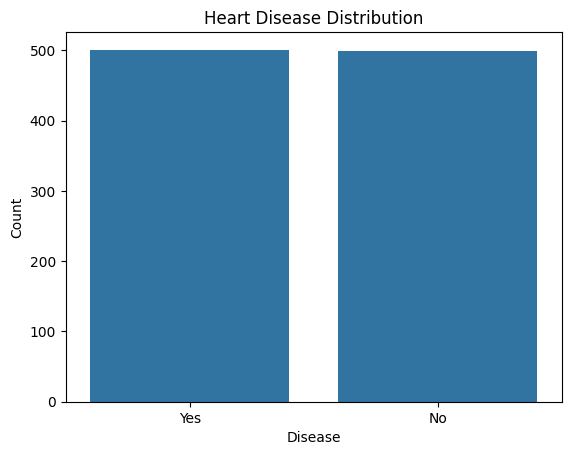

In [8]:
sns.countplot(
    x="disease",
    data=df
)

plt.title("Heart Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")

plt.show()

## Numerical Feature Distribution

This section explores the distribution of numerical variables.

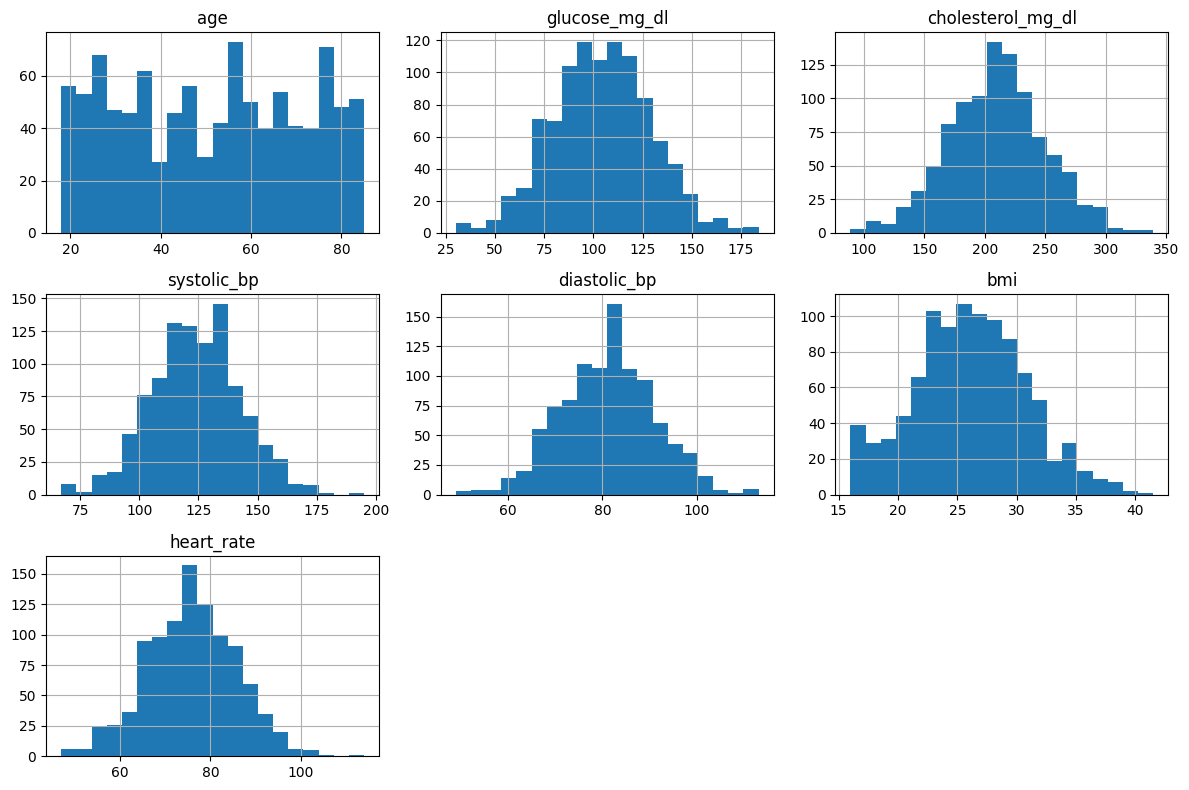

In [9]:
num_cols = [
    "age",
    "glucose_mg_dl",
    "cholesterol_mg_dl",
    "systolic_bp",
    "diastolic_bp",
    "bmi",
    "heart_rate"
]

df[num_cols].hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()

## Correlation Heatmap

Categorical variables are encoded temporarily to calculate correlation.

In [10]:
eda_df = df.copy()

for col in eda_df.select_dtypes("object"):
    eda_df[col] = LabelEncoder().fit_transform(
        eda_df[col]
    )

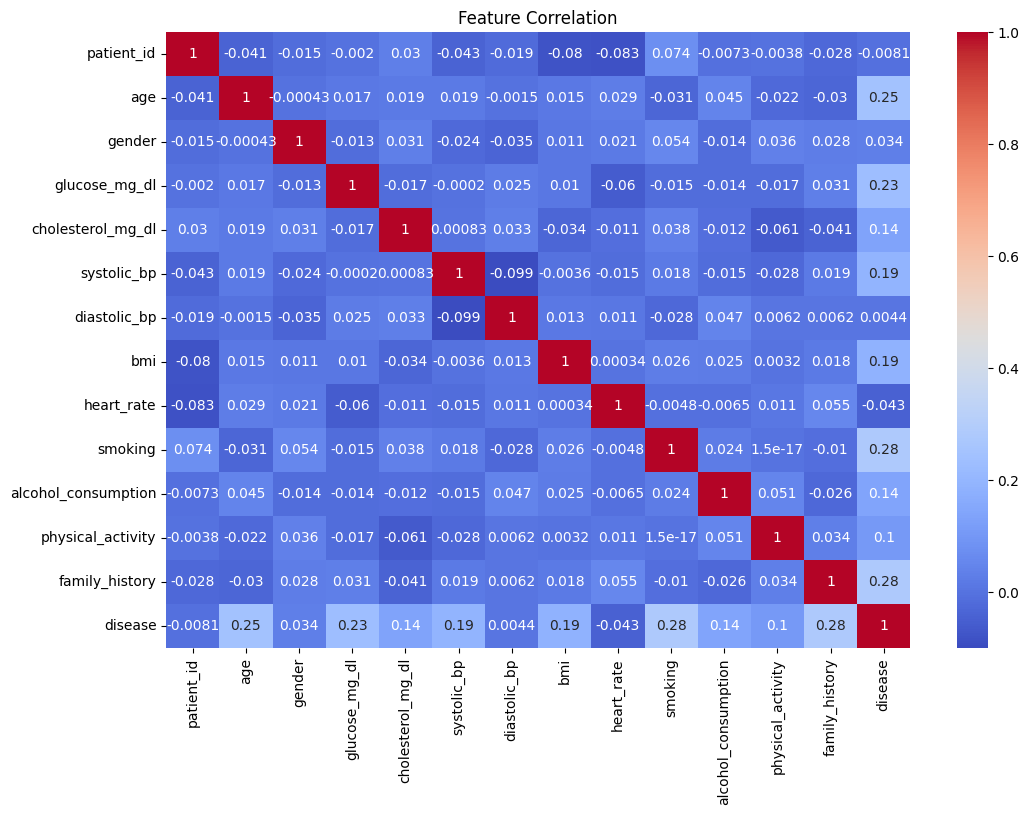

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    eda_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

## Feature Comparison Against Target

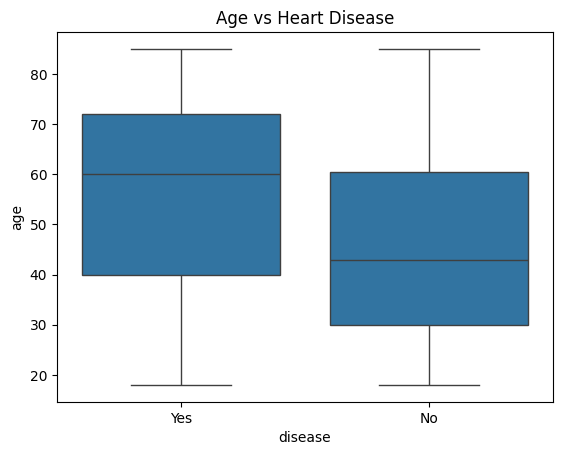

In [12]:
sns.boxplot(
    x="disease",
    y="age",
    data=df
)

plt.title("Age vs Heart Disease")
plt.show()

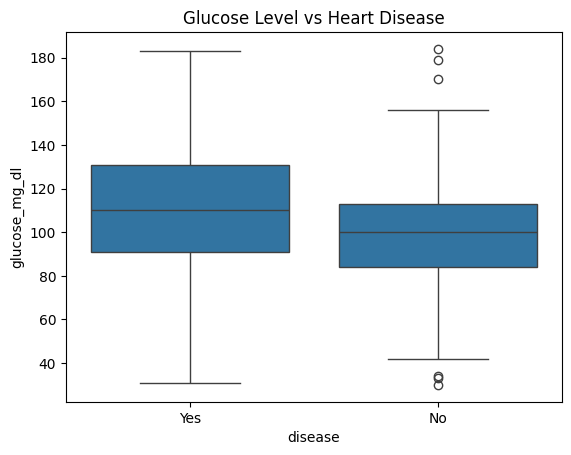

In [13]:
sns.boxplot(
    x="disease",
    y="glucose_mg_dl",
    data=df
)

plt.title("Glucose Level vs Heart Disease")
plt.show()

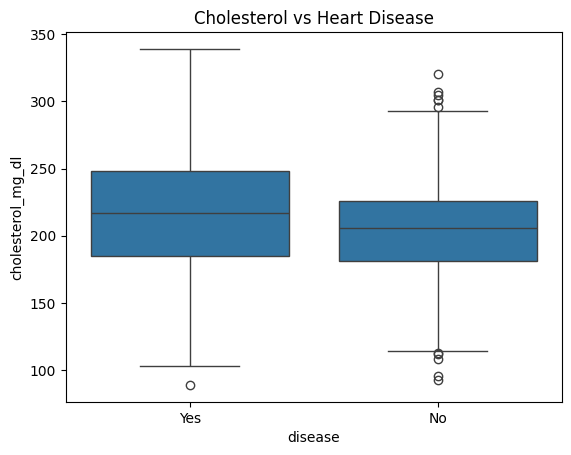

In [14]:
sns.boxplot(
    x="disease",
    y="cholesterol_mg_dl",
    data=df
)

plt.title("Cholesterol vs Heart Disease")
plt.show()

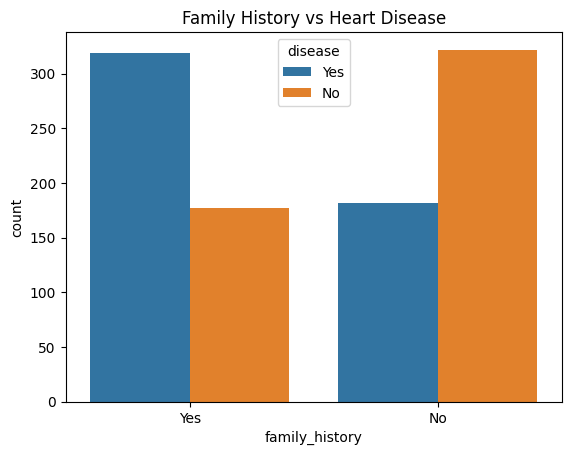

In [15]:
sns.countplot(
    x="family_history",
    hue="disease",
    data=df
)

plt.title("Family History vs Heart Disease")
plt.show()

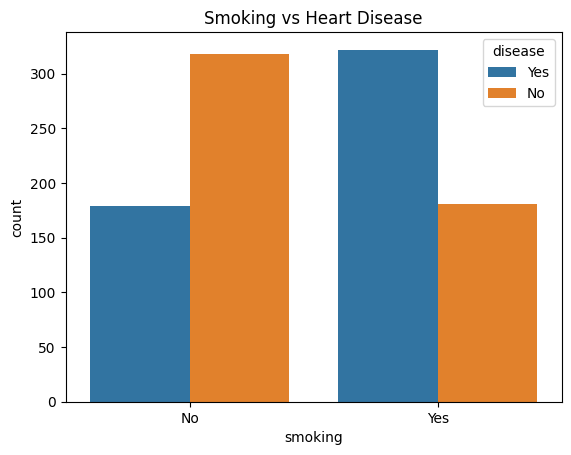

In [17]:
sns.countplot(
    x="smoking",
    hue="disease",
    data=df
)

plt.title("Smoking vs Heart Disease")
plt.show()

## EDA Summary

### **Target Distribution**
The target variable is balanced between patients with heart disease and without heart disease. This balanced distribution is suitable for machine learning classification.

### **Numerical Features**
Most numerical variables show relatively normal distributions. Glucose, cholesterol, blood pressure, BMI, and heart rate are concentrated within expected ranges.

### **Correlation Analysis**
Most features have weak to moderate correlation with heart disease. Smoking, family history, age, and glucose level show the strongest positive relationship with the target.

### **Age vs Heart Disease**
Patients diagnosed with heart disease tend to be older than patients without heart disease.

## **Glucose and Cholesterol**
Patients with heart disease generally have slightly higher glucose and cholesterol levels.

### **Family History and Smoking**
Family history and smoking show clear patterns, where patients with these risk factors are more likely to have heart disease.

### **Conclusion**
The EDA results indicate that age, glucose level, cholesterol, smoking, and family history may be important predictors for the next stage of model development.

# 7. Data Preprocessing

This stage prepares the dataset before machine learning model training.

The preprocessing steps include:
- removing unnecessary columns
- encoding categorical variables
- splitting features and target
- train-test split
- feature scaling

## Remove Unnecessary Columns

In [18]:
df = df.drop(
    "patient_id",
    axis=1
)

df.head()

,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


## Encode Categorical Variables

Categorical features are converted into numerical values so they can be used in machine learning models.

In [19]:
from sklearn.preprocessing import LabelEncoder

cat_cols = [
    "gender",
    "smoking",
    "alcohol_consumption",
    "physical_activity",
    "family_history",
    "disease"
]

encoders = {}

for col in cat_cols:
    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col]
    )

    encoders[col] = le

In [20]:
df.head()

,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,32,1,101,235,152,79,28.5,73,0,1,1,1,1
1,31,1,124,191,134,77,33.9,71,0,1,1,1,1
2,45,1,57,141,114,71,27.2,79,1,1,1,0,0
3,75,0,69,268,120,82,21.5,61,1,1,2,0,1
4,53,1,107,163,131,75,23.3,73,1,0,1,1,1


## Split Features and Target

In [21]:
X = df.drop(
    "disease",
    axis=1
)

y = df["disease"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1000, 12)
Target shape: (1000,)


## Train-Test Split

The dataset is divided into training data and testing data.

- **80%** training
- **20%** testing

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (800, 12)
X_test : (200, 12)
y_train: (800,)
y_test : (200,)


## Feature Scaling

Numerical features are standardized before training.

This step is especially important for Logistic Regression.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

## Preprocessing Summary

### **Column Removal**
The `patient_id` column was removed because it does not contribute to prediction.

### **Encoding**
Categorical variables were converted into numerical values using Label Encoding.

### **Data Split**
The dataset was split into training and testing sets using an 80:20 ratio.

### **Feature Scaling**
Numerical features were standardized to prepare the dataset for machine learning models.

# 8. Model Training

This stage trains multiple machine learning classification models to predict heart disease.

The models used in this project are:

- Logistic Regression
- Decision Tree
- Random Forest

The objective is to compare performance and identify the most suitable model.

## Logistic Regression

Logistic Regression is used as a baseline classification model.

Because it is sensitive to feature scale, the model is trained using the standardized dataset.

In [27]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42
)

lr.fit(
    X_train_scaled,
    y_train
)

pred_lr = lr.predict(
    X_test_scaled
)

In [28]:
pred_lr[:10]

array([1, 1, 0, 0, 0, 1, 1, 1, 0, 0])

## Decision Tree

Decision Tree learns classification rules by splitting the dataset based on feature values.

In [29]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

pred_dt = dt.predict(
    X_test
)

In [30]:
pred_dt[:10]

array([1, 0, 0, 0, 1, 1, 1, 1, 1, 0])

## Random Forest

Random Forest combines multiple decision trees and usually provides stronger performance and more stable predictions.

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(
    X_test
)

In [32]:
pred_rf[:10]

array([1, 0, 0, 0, 1, 1, 1, 1, 0, 0])

## Model Training Summary

Three classification models were trained using the prepared dataset:

- Logistic Regression
- Decision Tree
- Random Forest

Prediction results from each model were generated and will be evaluated in the next stage using classification metrics.

# 9. Model Evaluation

This stage evaluates the performance of each classification model.

The evaluation metrics used are:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC Curve

The objective is to compare model performance and identify the best-performing model before hyperparameter tuning.

## Evaluation Function

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def evaluate_model(
    name,
    y_true,
    y_pred
):
    print(name)

    print(
        "Accuracy :",
        round(
            accuracy_score(
                y_true,
                y_pred
            ),
            4
        )
    )

    print(
        "Precision:",
        round(
            precision_score(
                y_true,
                y_pred
            ),
            4
        )
    )

    print(
        "Recall   :",
        round(
            recall_score(
                y_true,
                y_pred
            ),
            4
        )
    )

    print(
        "F1 Score :",
        round(
            f1_score(
                y_true,
                y_pred
            ),
            4
        )
    )

    print("\nClassification Report")

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

    print("-" * 50)

## Evaluate Logistic Regression

In [34]:
evaluate_model(
    "Logistic Regression",
    y_test,
    pred_lr
)

Logistic Regression
Accuracy : 0.74
Precision: 0.75
Recall   : 0.72
F1 Score : 0.7347

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.76      0.75       100
           1       0.75      0.72      0.73       100

    accuracy                           0.74       200
   macro avg       0.74      0.74      0.74       200
weighted avg       0.74      0.74      0.74       200

--------------------------------------------------


## Evaluate Decision Tree

In [35]:
evaluate_model(
    "Decision Tree",
    y_test,
    pred_dt
)

Decision Tree
Accuracy : 0.84
Precision: 0.8617
Recall   : 0.81
F1 Score : 0.8351

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       100
           1       0.86      0.81      0.84       100

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200

--------------------------------------------------


## Evaluate Random Forest (Best Model)


In [36]:
evaluate_model(
    "Random Forest",
    y_test,
    pred_rf
)

Random Forest
Accuracy : 0.915
Precision: 0.9029
Recall   : 0.93
F1 Score : 0.9163

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       100
           1       0.90      0.93      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200

--------------------------------------------------


**Random Forest** achieved the **highest overall performance** among the baseline models.

It produced strong accuracy and recall while maintaining balanced predictions.

For this reason, Random Forest was selected for further evaluation using the Confusion Matrix and ROC Curve to better visualize classification performance before hyperparameter tuning.

## Confusion Matrix

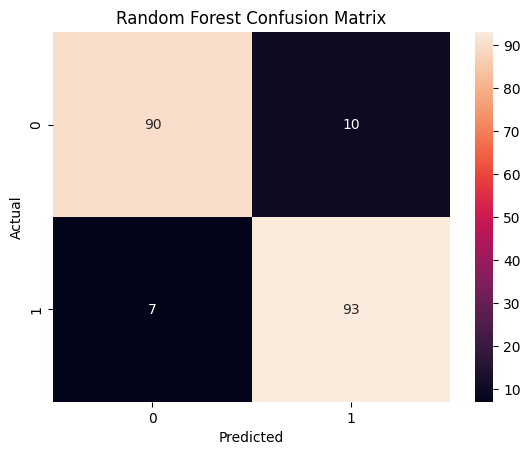

In [37]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## ROC Curve

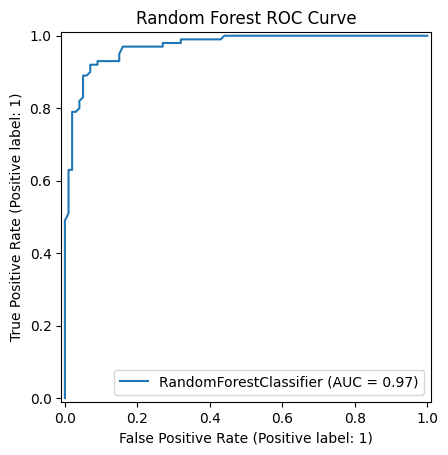

In [39]:
RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title(
    "Random Forest ROC Curve"
)

plt.show()

## Model Evaluation Summary

### **Logistic Regression**
Logistic Regression performed well as a baseline model and provided stable predictions after feature scaling.

### **Decision Tree**
Decision Tree achieved acceptable performance, but the results were lower than the other models and showed less balanced predictions.

### **Random Forest**
Random Forest produced the best performance among all baseline models.

Performance metrics:
- Accuracy: **91.5%**
- Precision: **90.3%**
- Recall: **93.0%**
- F1 Score: **91.6%**

### **Confusion Matrix**
The Random Forest model correctly classified most observations.

Results:
- True Negative: **90**
- False Positive: **10**
- False Negative: **7**
- True Positive: **93**

The model shows strong ability to identify patients with heart disease while keeping prediction errors relatively low.

### **ROC Curve**
The ROC Curve shows strong classification performance with an AUC of **0.97**.

This indicates the model can effectively distinguish between patients with and without heart disease.

### **Conclusion**
Among the baseline models, Random Forest achieved the best overall performance.

Because of its strong accuracy and recall, Random Forest will be selected for hyperparameter tuning in the next stage.

# 10. Hyperparameter Tuning

After evaluating the baseline models, Random Forest was selected for optimization because it achieved the best overall performance.

Hyperparameter tuning is performed using GridSearchCV to test multiple parameter combinations and identify the best-performing configuration.

## Define Hyperparameter Grid

In [42]:
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

## Run GridSearchCV

In [43]:
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(n_estimators=200,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, None], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

## Best Parameters

In [44]:
print("Best Parameters:")
print(grid_rf.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


## Train Tuned Random Forest

In [45]:
best_rf = grid_rf.best_estimator_

pred_best_rf = best_rf.predict(
    X_test
)

## Evaluate Tuned Model

In [46]:
evaluate_model(
    "Tuned Random Forest",
    y_test,
    pred_best_rf
)

Tuned Random Forest
Accuracy : 0.915
Precision: 0.9029
Recall   : 0.93
F1 Score : 0.9163

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       100
           1       0.90      0.93      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200

--------------------------------------------------


## Compare Baseline vs Tuned Model

In [47]:
baseline_accuracy = accuracy_score(
    y_test,
    pred_rf
)

tuned_accuracy = accuracy_score(
    y_test,
    pred_best_rf
)

print("Baseline Random Forest :", round(baseline_accuracy, 4))
print("Tuned Random Forest    :", round(tuned_accuracy, 4))

Baseline Random Forest : 0.915
Tuned Random Forest    : 0.915


## Hyperparameter Tuning Summary

### **Best Parameters**
GridSearchCV selected the following parameter combination for Random Forest:

- **n_estimators:** 200
- **max_depth:** None
- **min_samples_split:** 2
- **min_samples_leaf:** 1

### **Tuned Model Performance**
The tuned Random Forest model achieved:

- Accuracy: **91.5%**
- Precision: **90.3%**
- Recall: **93.0%**
- F1 Score: **91.6%**

### **Baseline vs Tuned Model**
The baseline and tuned Random Forest models produced the same performance.

This indicates that the original model configuration already performed well and was the best combination among the tested parameters.

### **Conclusion**
Hyperparameter tuning confirmed that Random Forest remains the best-performing model.

The tuning process did not improve performance further, but it validated that the selected model is already well optimized for this dataset.

# 11. Feature Importance

This section identifies which features contribute the most to the final Random Forest model.

Feature importance helps interpret the model and understand which patient characteristics have the strongest influence on heart disease prediction.

## Calculate Feature Importance

In [48]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
2,glucose_mg_dl,0.171726
0,age,0.132271
6,bmi,0.122918
3,cholesterol_mg_dl,0.104476
4,systolic_bp,0.091122
10,physical_activity,0.089619
8,smoking,0.082570
11,family_history,0.059278
5,diastolic_bp,0.055279
7,heart_rate,0.053353


## Feature Importance Visualization

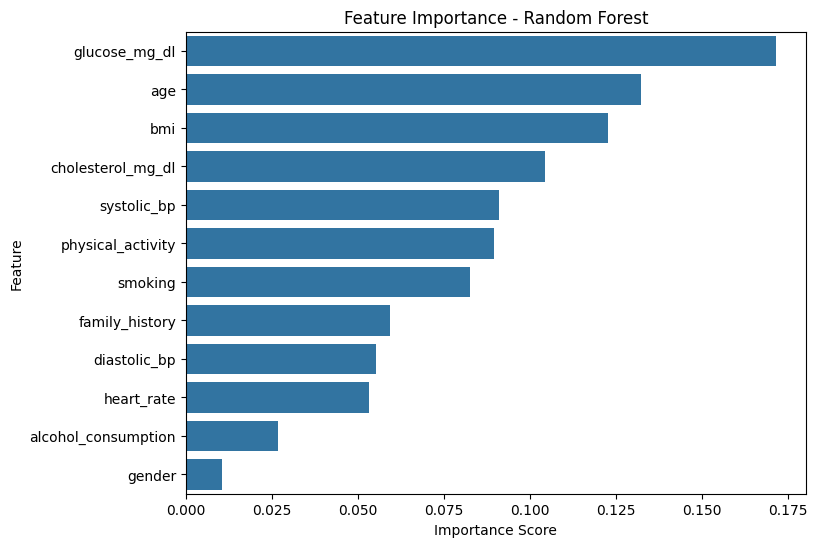

In [49]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="importance",
    y="feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

## Feature Importance Summary

### **Most Important Features**
The Random Forest model shows that the most important features in predicting heart disease are:

- **Glucose level** (0.172)
- **Age** (0.132)
- **BMI** (0.123)
- **Cholesterol level** (0.104)
- **Systolic blood pressure** (0.091)

These features contribute the most to the prediction results.

### **Lifestyle and Medical History**
Lifestyle-related variables such as physical activity and smoking also contribute to the model.

Family history has moderate importance, indicating that medical history still plays a role in predicting heart disease.

### **Lower Importance Features**
Alcohol consumption and gender show the lowest contribution compared with other variables.

This suggests these variables have less influence on prediction in this dataset.

### **Conclusion**
Feature importance shows that clinical indicators such as glucose level, age, BMI, cholesterol, and blood pressure are the strongest predictors of heart disease.

Lifestyle and medical history variables also contribute, but with lower importance compared with the main clinical indicators.

# 12. Final Conclusion

This project developed a machine learning model to predict heart disease based on patient clinical and lifestyle indicators.

### **Model Performance**
Three baseline classification models were trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Among them, **Random Forest** achieved the best overall performance with:

- **Accuracy:** 91.5%
- **Precision:** 90.3%
- **Recall:** 93.0%
- **F1 Score:** 91.6%
- **AUC:** 0.97

This indicates that the model can effectively distinguish between patients with and without heart disease.

### **Hyperparameter Tuning**
Hyperparameter tuning was performed using GridSearchCV.

The tuned model produced the same performance as the baseline Random Forest, confirming that the original model configuration was already well optimized for this dataset.

### **Key Findings**
The most important predictors identified by the model were:

- glucose level
- age
- BMI
- cholesterol level
- systolic blood pressure

Lifestyle variables such as smoking and physical activity also contributed to the prediction.

### **Final Summary**
This project demonstrates a complete machine learning workflow:

- data exploration
- exploratory data analysis
- preprocessing
- model training
- model evaluation
- hyperparameter tuning
- feature importance analysis

Overall, the Random Forest model performed well and showed strong potential for predicting heart disease using patient clinical and lifestyle information.